In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import wandb
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
train_data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
test_data  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

print(f"Train: {len(train_data.data)} | Test: {len(test_data.data)} | Classes: {len(train_data.target_names)}")

Train: 11314 | Test: 7532 | Classes: 20


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN   = 128

print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded.


In [ ]:
class MLMDataset(Dataset):
    def __init__(self, texts):
        # Tokenize all texts — no labels needed, MLM is self-supervised
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
        }

# Use all text (train + test) for MLM — labels are not needed here
all_texts   = train_data.data + test_data.data
mlm_dataset = MLMDataset(all_texts)

# DataCollatorForLanguageModeling automatically masks 15% of tokens
mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15   # standard masking rate from the original BERT paper
)

mlm_loader = DataLoader(mlm_dataset, batch_size=16, shuffle=True,
                        collate_fn=mlm_collator)

print(f"MLM dataset size: {len(mlm_dataset)} documents")

MLM dataset size: 18846 documents


In [ ]:
MLM_EPOCHS = 2   # 2 epochs is enough for domain adaptation — more risks overfitting
MLM_LR     = 5e-5

mlm_model = BertForMaskedLM.from_pretrained("bert-base-uncased").to(DEVICE)
optimizer = AdamW(mlm_model.parameters(), lr=MLM_LR)

wandb.init(
    project="nalapro-20newsgroups",
    name="bert-mlm-pretraining",
    config={"epochs": MLM_EPOCHS, "lr": MLM_LR,
            "mlm_probability": 0.15, "max_len": MAX_LEN}
)

print("Starting MLM pretraining...")
for epoch in range(1, MLM_EPOCHS + 1):
    mlm_model.train()
    total_loss, total = 0, 0

    for batch in mlm_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = mlm_model(input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), 1.0)
        optimizer.step()

        total_loss += outputs.loss.item() * len(input_ids)
        total      += len(input_ids)

    avg_loss = total_loss / total
    wandb.log({"epoch": epoch, "mlm_loss": avg_loss})
    print(f"  Epoch {epoch}/{MLM_EPOCHS} | mlm_loss={avg_loss:.4f}")

wandb.finish()
print("\nMLM pretraining complete.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


...

wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gichukicynthia (gichukicynthia-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting MLM pretraining...
  Epoch 1/2 | mlm_loss=2.4708
  Epoch 2/2 | mlm_loss=2.2919


epoch,▁█
mlm_loss,█▁
epoch,2
mlm_loss,2.29185



MLM pretraining complete.


In [ ]:
import os, shutil
from google.colab import files

os.makedirs("nalapro/bert_mlm", exist_ok=True)
mlm_model.save_pretrained("nalapro/bert_mlm")
tokenizer.save_pretrained("nalapro/bert_mlm")

shutil.make_archive("bert_mlm", "zip", "nalapro/bert_mlm")
files.download("bert_mlm.zip")
print("MLM model saved and downloading...")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MLM model saved and downloading...


In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = ClassificationDataset(train_data.data, train_data.target)
test_dataset  = ClassificationDataset(test_data.data,  test_data.target)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print("Classification datasets ready.")

Classification datasets ready.


In [ ]:
CLS_EPOCHS = 3
CLS_LR     = 2e-5

# Start from the MLM-adapted weights, not vanilla bert-base-uncased
cls_model = BertForSequenceClassification.from_pretrained(
    "nalapro/bert_mlm",
    num_labels=20,
    ignore_mismatched_sizes=True   # classification head is new so sizes differ
).to(DEVICE)

optimizer = AdamW(cls_model.parameters(), lr=CLS_LR)
total_steps  = len(train_loader) * CLS_EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer, total_steps // 10, total_steps)

print(f"Classification model loaded from MLM weights.")
print(f"Total training steps: {total_steps}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: nalapro/bert_mlm
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Classification model loaded from MLM weights.
Total training steps: 2124


In [ ]:
wandb.init(
    project="nalapro-20newsgroups",
    name="bert-mlm-then-classify",
    config={"cls_epochs": CLS_EPOCHS, "cls_lr": CLS_LR,
            "mlm_epochs": MLM_EPOCHS, "max_len": MAX_LEN}
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, CLS_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{CLS_EPOCHS}")

    # Train
    cls_model.train()
    t_loss, t_correct, total = 0, 0, 0
    for batch in train_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = cls_model(input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(cls_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        t_loss    += outputs.loss.item() * len(labels)
        t_correct += (outputs.logits.argmax(1) == labels).sum().item()
        total     += len(labels)

    t_loss /= total;  t_acc = t_correct / total

    # Validate
    cls_model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            outputs        = cls_model(input_ids, attention_mask=attention_mask, labels=labels)
            v_loss    += outputs.loss.item() * len(labels)
            v_correct += (outputs.logits.argmax(1) == labels).sum().item()
            v_total   += len(labels)

    v_loss /= v_total;  v_acc = v_correct / v_total

    wandb.log({"epoch": epoch, "train_loss": t_loss, "train_acc": t_acc,
                               "val_loss":   v_loss, "val_acc":   v_acc})
    for k, v in zip(history, [t_loss, v_loss, t_acc, v_acc]):
        history[k].append(v)

    print(f"  train_loss={t_loss:.3f}  train_acc={t_acc:.3f} | val_loss={v_loss:.3f}  val_acc={v_acc:.3f}")

print("\nClassification training complete.")


Epoch 1/3
  train_loss=1.627  train_acc=0.549 | val_loss=1.076  val_acc=0.680

Epoch 2/3
  train_loss=0.794  train_acc=0.765 | val_loss=1.011  val_acc=0.702

Epoch 3/3
  train_loss=0.557  train_acc=0.839 | val_loss=1.012  val_acc=0.709

Classification training complete.


In [ ]:
cls_model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        preds = cls_model(input_ids, attention_mask=attention_mask).logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())

acc_bert_mlm = accuracy_score(test_data.target, all_preds)
print(f"BERT (MLM → Classification) Test Accuracy: {acc_bert_mlm:.4f}")
print(classification_report(test_data.target, all_preds,
                             target_names=test_data.target_names, zero_division=0))

wandb.log({"final_test_accuracy": acc_bert_mlm})
wandb.finish()

BERT (MLM → Classification) Test Accuracy: 0.7086
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.52      0.51       319
           comp.graphics       0.68      0.69      0.68       389
 comp.os.ms-windows.misc       0.66      0.67      0.66       394
comp.sys.ibm.pc.hardware       0.66      0.68      0.67       392
   comp.sys.mac.hardware       0.80      0.71      0.75       385
          comp.windows.x       0.84      0.76      0.80       395
            misc.forsale       0.86      0.83      0.85       390
               rec.autos       0.55      0.75      0.64       396
         rec.motorcycles       0.73      0.74      0.74       398
      rec.sport.baseball       0.90      0.80      0.85       397
        rec.sport.hockey       0.88      0.88      0.88       399
               sci.crypt       0.76      0.71      0.73       396
         sci.electronics       0.64      0.63      0.63       393
                 sci.med 

epoch,▁▅█
final_test_accuracy,▁
train_acc,▁▆█
train_loss,█▃▁
val_acc,▁▇█
val_loss,█▁▁
epoch,3
final_test_accuracy,0.70858
train_acc,0.83914
train_loss,0.55702
val_acc,0.70858


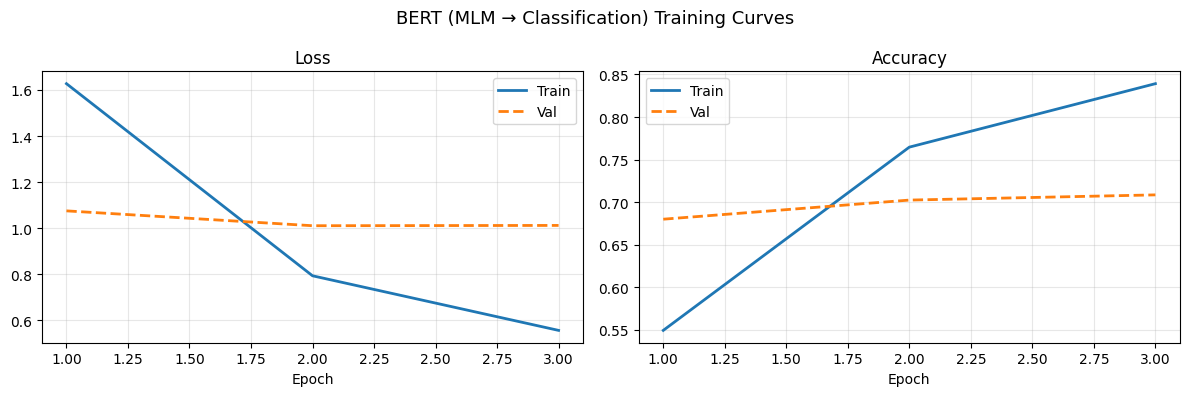

In [ ]:
epochs = range(1, CLS_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("BERT (MLM → Classification) Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("bert_mlm_curves.png", dpi=150)
plt.show()

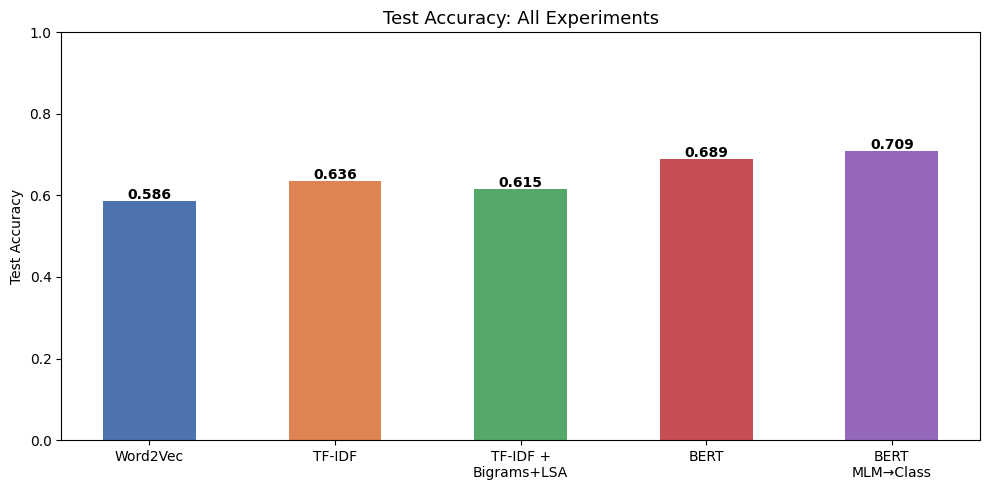

In [ ]:
# Results from Task 1 and 2
acc_w2v   = 0.586
acc_tfidf = 0.636
acc_lsa   = 0.615
acc_bert   = 0.689

labels = ["Word2Vec", "TF-IDF", "TF-IDF +\nBigrams+LSA", "BERT", "BERT\nMLM→Class"]
accs   = [acc_w2v, acc_tfidf, acc_lsa, acc_bert, acc_bert_mlm]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467BD"]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, accs, color=colors, width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", fontweight="bold")
plt.ylim(0, 1); plt.ylabel("Test Accuracy")
plt.title("Test Accuracy: All Experiments", fontsize=13)
plt.tight_layout()
plt.savefig("all_tasks_comparison.png", dpi=150)
plt.show()

In [ ]:
import json
from google.colab import files

results = {
    "final_accuracy": acc_bert_mlm,
    "history": history
}
with open("bert_mlm_results.json", "w") as f:
    json.dump(results, f)

files.download("bert_mlm_results.json")
files.download("bert_mlm_curves.png")
files.download("all_tasks_comparison.png")
print("All files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded.


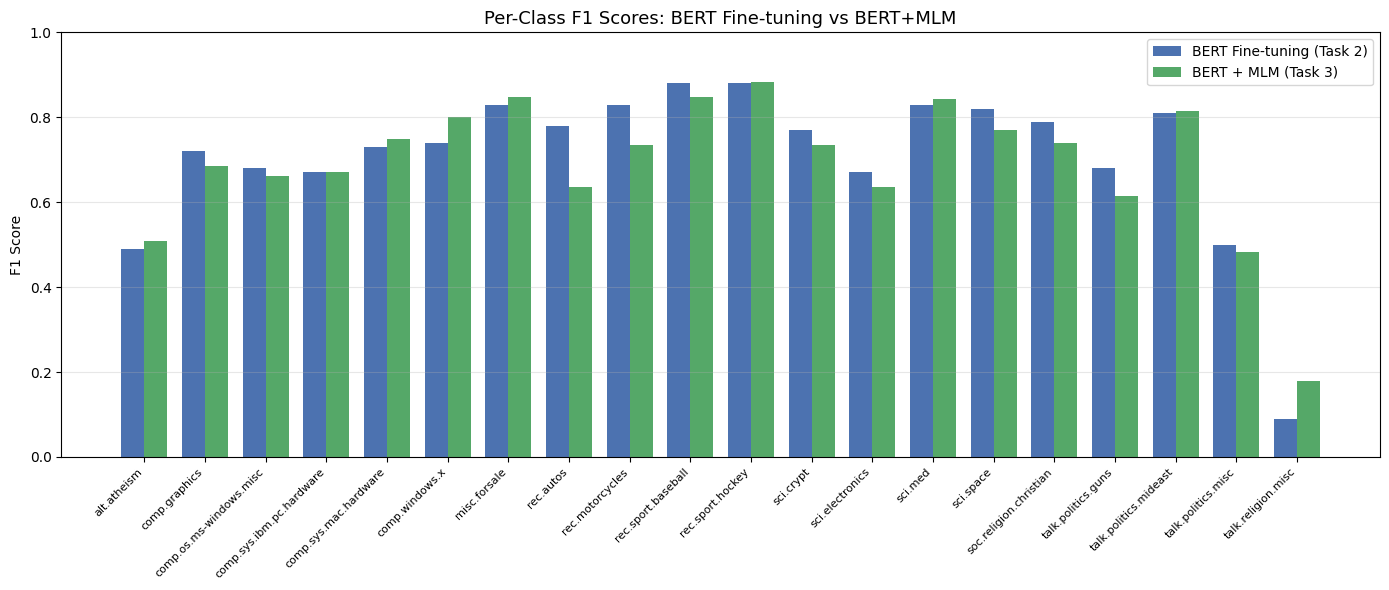

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# all_preds here = MLM model predictions (already computed above)
report_mlm = classification_report(test_data.target, all_preds,
                                   target_names=test_data.target_names,
                                   zero_division=0, output_dict=True)

# Task 2 BERT F1 values — hardcoded from NLP_Project_BERT.ipynb output
bert2_f1 = {
    'alt.atheism': 0.49, 'comp.graphics': 0.72, 'comp.os.ms-windows.misc': 0.68,
    'comp.sys.ibm.pc.hardware': 0.67, 'comp.sys.mac.hardware': 0.73,
    'comp.windows.x': 0.74, 'misc.forsale': 0.83, 'rec.autos': 0.78,
    'rec.motorcycles': 0.83, 'rec.sport.baseball': 0.88, 'rec.sport.hockey': 0.88,
    'sci.crypt': 0.77, 'sci.electronics': 0.67, 'sci.med': 0.83,
    'sci.space': 0.82, 'soc.religion.christian': 0.79, 'talk.politics.guns': 0.68,
    'talk.politics.mideast': 0.81, 'talk.politics.misc': 0.50, 'talk.religion.misc': 0.09
}

classes  = test_data.target_names
f1_bert2 = [bert2_f1[c] for c in classes]
f1_mlm   = [report_mlm[c]["f1-score"] for c in classes]

x     = np.arange(len(classes))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_bert2, width, label="BERT Fine-tuning (Task 2)", color="#4C72B0")
ax.bar(x + width/2, f1_mlm,   width, label="BERT + MLM (Task 3)",       color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.set_title("Per-Class F1 Scores: BERT Fine-tuning vs BERT+MLM", fontsize=13)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1_heatmap.png", dpi=150)
plt.show()